In [117]:
using Bloqade #Átomos neutros de QuEra
using Bloqade.CairoMakie #Para gráficar
using LinearAlgebra #Para cálculos entre estados
using OrdinaryDiffEq #Paquete para resolver la ecuación de Schrödinger
using Yao #Para trabajar con los estados de qubits.
using Random #Para simulaciones de Monte Carlo
using Optim #Para optimizar la posición de los átomos en la red
using StatsBase #Para sacar información de medidas

# Problema de la mochila

En este cuaderno implementamos en átomos neutros un análogo al problema de la mochila. Tendremos cuatro T-bills con distintos valores de retorno y riesgo medio. La clave está en que ahora existe correlación entre los activos.

La situación es la siguiente, disponemos de los siguientes activos:
*  **Activo 1:** Retorno alto (8%), pero muy volátil (riesgo propio = 10).
*  **Activo 2:** Retorno bueno (6%), riesgo medio (5).
*  **Activo 3:** Retorno medio (5%), riesgo medio (6). Muy correlacionado con el **activo 1**, si se compran a la vez el riesgo conjunto se dispara.
*  **Activo 4:** Retorno bajo (3%), riesgo casi nulo (2).

Pasemos a analizar cómo son los vectores que representan esta situación. Definimos un vector de retornos $\mu = (8, 6, 5, 3)$ y una matriz de covarianza  $$\Sigma = \begin{pmatrix} 10 & 2 & 8 & 1 \\ 2 & 5 & 3 & 0 \\ 8 & 3 & 6 & 1 \\ 1 & 0 & 1 & 2 \end{pmatrix}$$
La última restricción es que solo tenemos presupuesto para comprar dos activos.

In [118]:
#Vector de retornos:
μ = [8.0, 7.0, 5.0 ,3.0]

#Matriz de correlaciones
sigma = [ 10.0 2.0 8.0 1.0;
           2.0 5.0 3.0 0.0;
           8.0 3.0 6.0 1.0;
           1.0 0.0 1.0 2.0];


## Transformación QUBO:

Para pasar a unas variables binarias $x_i \in \{0,1\}$ que representen si compramos o no un activo, definimos una función coste como sigue:
$$H = -\underbrace{\sum \mu_i x_i}_{\text{Retorno}} + \gamma \underbrace{\sum_{i,j} x_i \Sigma_{ij} x_j}_{\text{Riesgo}} + \lambda \underbrace{\left( \sum x_i - 2 \right)^2}_{\text{Restricción: Elegir 2}}$$

Expandiendo el término de restricción obtenemos:
$$\lambda (\sum x_i - 2)^2 = \lambda \left( (\sum x_i)^2 - 4\sum x_i + 4 \right)$$
Y aplicando la propiedad $x_i^2 = x_i$ podemos agrupar términos en dos tipos:
*  Términos lineales ($x_i$): forman la diagonal de una matriz Q.
*  Términos cuadráticos ($x_ix_j$): forman las interacciones de la matriz Q.

Pasamos entonces a calcular estos elementos. Para un número de activos $K$, la expansión de $\lambda (\sum{x_i-K})^2$ da unas fórmulas exactas para términos lineales y cuadráticos:
* Términos lineales (Diagonal $Q_{ii}$):
 $$Q_{ii} = -\mu_i + \gamma \Sigma_{ii} + \lambda (1 - 2K)$$
* Términos cuadráticos (Cruces $Q_{ij}$, para $i \neq j$):
  $$Q_{ij} = 2\gamma \Sigma_{ij} + 2\lambda$$

In [119]:
#Parámetros del gestor:
K = 2 #Número exacto de activos.
gamma = 1.0 #Factor de aversión al riesgo.
lambda = 40.0 #Factor de penalización.

N_activos = length(μ)

#Construimos la matriz Q:
Q = zeros(Float64, N_activos, N_activos)

for i in 1:N_activos
    for j in 1:N_activos
        if i == j
            #Diagonal: términos lineales
            Q[i, i] = -μ[i] + gamma * sigma[i, i] + lambda * (1 - 2*K)
        elseif j > i
            #Fuera de la diagonal: términos de cruce
            Q[i, j] = 2 * gamma * sigma[i, j] + 2 * lambda
            Q[j, i] = Q[i, j]
        end
    end
end

## Mapeo en átomos neutros

Es hora de pasar el problema a los átomos neutros. La correlación entre activos se traduce en interacciones de Van der Waals que darán lugar a mayor o menor probabilidad de que ocurra el bloqueo Rydberg.

Vamos a implementar una función que para una matriz Q sea capaz de generar la disposición espacial (en $2D$) óptima de los átomos dada en micrómetros. Para ello se hace uso de funciones optimizadoras del paquete Optim y tenemos en cuenta que el valor de la fuerza de interacción de Van der Waals es:
$$ V_{ij} = \frac{C_6}{R_{ij}^6} $$
donde $C_6 = \frac{862690.0}{2π}\hspace{0.1cm} MHz \hspace{0.1cm} μm^{-6}$ es la constante de Rydberg C6 para el átomo de Rb-87

Optimización finalizada con un Error cuadrático de: 402.2939


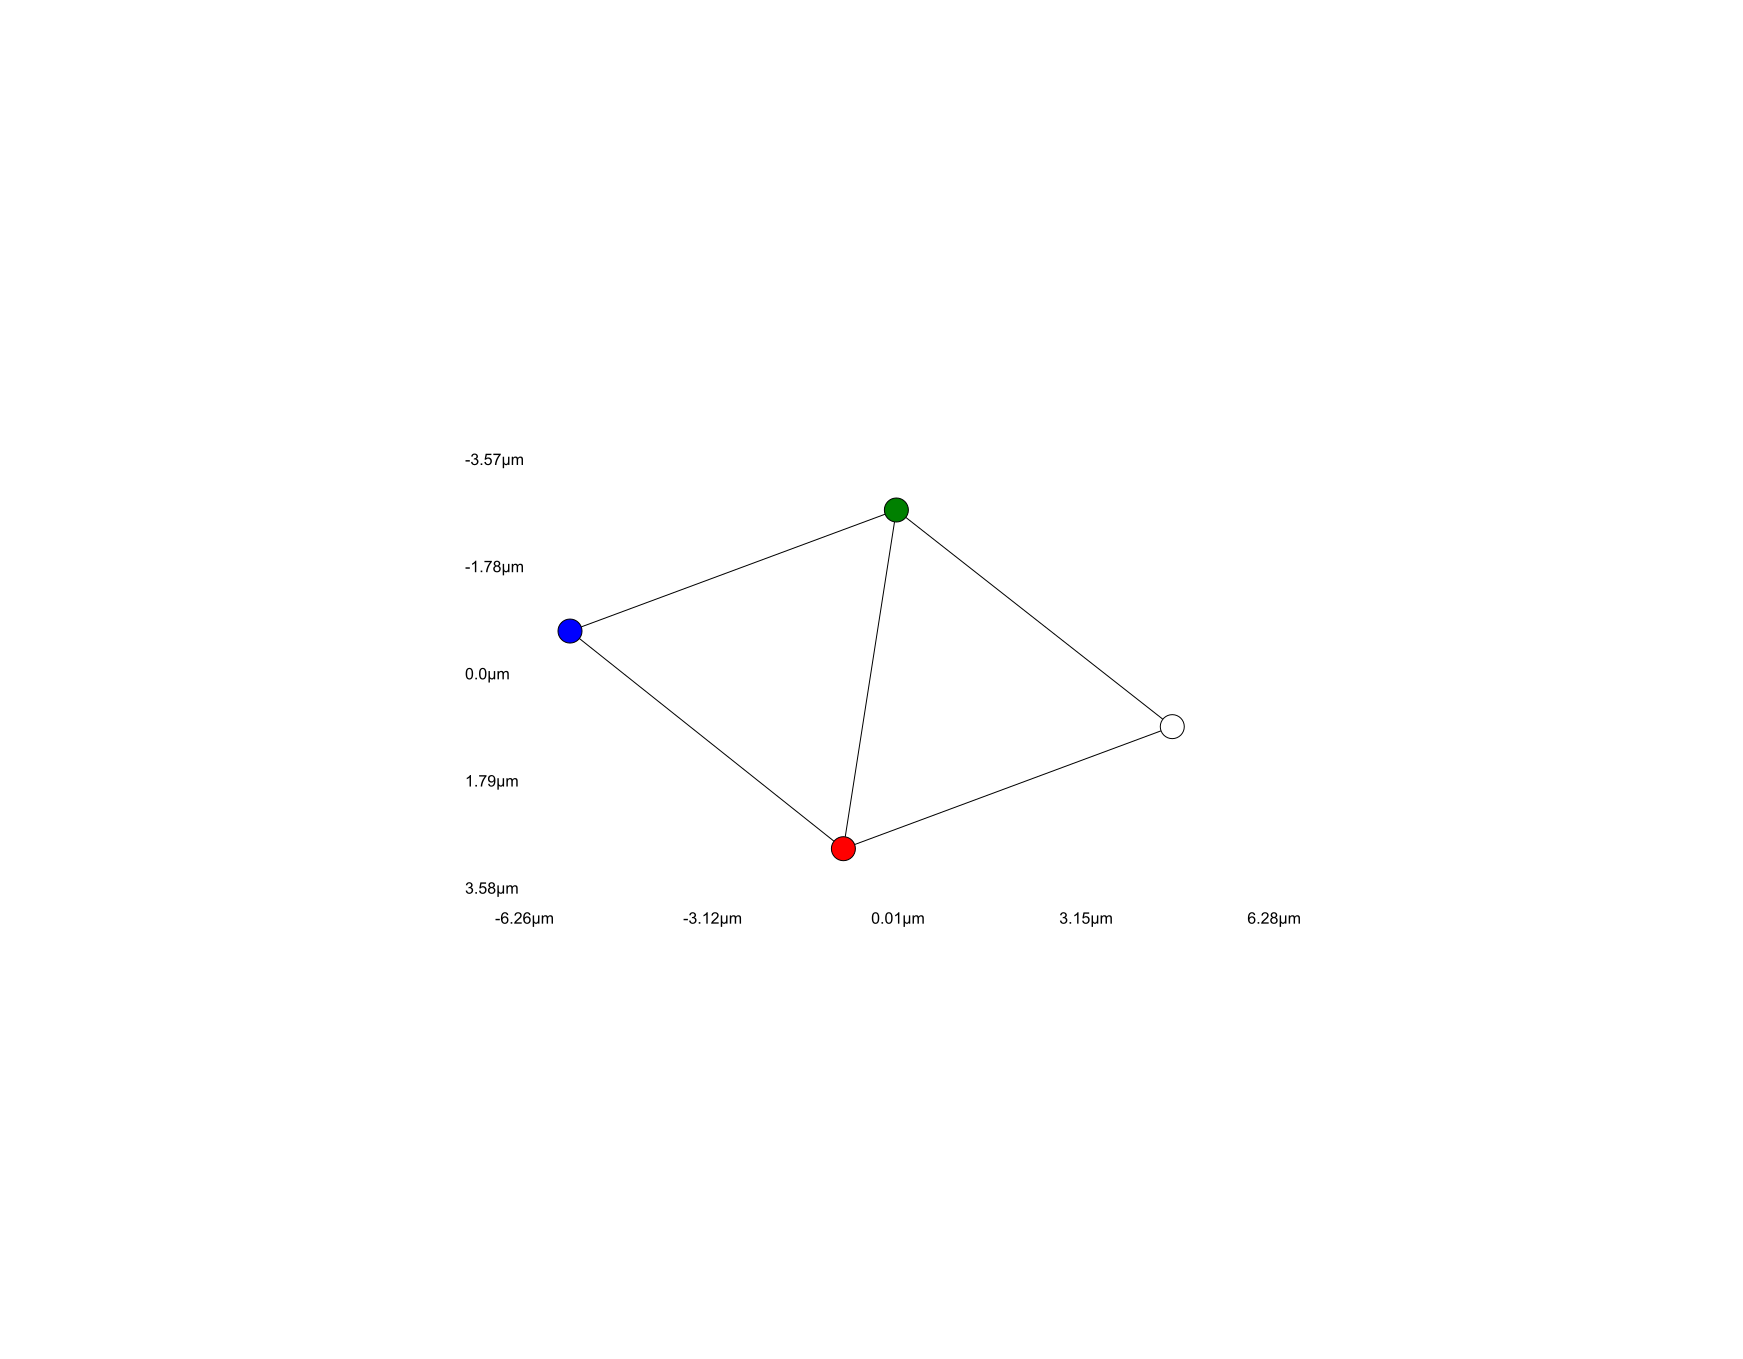

In [126]:
function geometria_QUBO(Q::Matrix{Float64}, activos::Vector{String},C6::Float64=862690.0)
    " Esta función recibe la matriz QUBO (Q) y la constante de Rydberg.
    Devuelve las posiciones (x, y) en μm óptimas para el tratamiento en Bloqade. "
    N = size(Q, 1) 
    if length(activos) != N
        error("La cantidad de nombres de activos debe coincidir con el tamaño de Q.")
    end
    #Reescalamos Q para que los valores sean manejables
    Q_max = maximum(abs.(Q- diagm(diag(Q))))
    Q_scaled = Q ./ (Q_max/25)
    
    #Definimos la función de pérdida a minimizar
    function loss(coords)
        error_total = 0.0
        #coords es un vector plano (x1, y1, x2, y2...)
        for i in 1:N
            for j in (i+1):N
                #Extraemos coordenadas:
                xi, yi = coords[2i-1], coords[2i]
                xj, yj = coords[2j-1], coords[2j]

                #Calculamos la distancia al cuadrado:
                dist2 = (xi - xj)^2 + (yi - yj)^2

                #Evitamos que dos átomos estén en el mismo punto:
                dist2 = max(dist2, 1)

                #Calculamos la interacción de Van der Waals:
                V_ij = C6 / dist2^3

                #Sumamos el error cuadrático respecto a la matriz Q:
                error_total += (V_ij - Q_scaled[i,j])^2
            end
        end
        return error_total
    end
    #Hacemos 10 intentos para sacar la mejor disposición espacial:
    mejor_error = Inf
    mejores_pos = []
    for _ in 1:100
        coord_ini = randn(2 * N) .* 10
        resultado = optimize(loss, coord_ini, LBFGS())
        if Optim.minimum(resultado) < mejor_error
            mejor_error = Optim.minimum(resultado)
            mejores_pos = Optim.minimizer(resultado)
        end
    end
        
    

    #Lo damos en formato de tuplas para Bloqade
    posiciones0 = [(mejores_pos[2i-1] , mejores_pos[2i]) for i in 1:N]

    #Centramos en el origen:
    c_x = sum(p[1] for p in posiciones0) / N
    c_y = sum(p[2] for p in posiciones0) / N

    posiciones = [(p[1] - c_x, p[2] - c_y) for p in posiciones0]

    println("Optimización finalizada con un Error cuadrático de: ", round(first(mejor_error), digits = 4))
    return posiciones
end

Activos = ["red", "blue", "green", "white"]
posiciones = geometria_QUBO(Q,Activos)
atoms = AtomList(posiciones);
fig = Bloqade.plot(atoms, blockade_radius=7.0, colors = Activos);
fig #Esto a veces da problemas, basta con quitar y poner los ; para que acabe funcionando.

Ahora que disponemos de una geometría que posee de manera intrínseca las interacciones de nuetro sistema, podemos realizar el barrido adiabático que nos dará la solución al problema. Pasamos a definir los valores y duraciones de los pulsos.

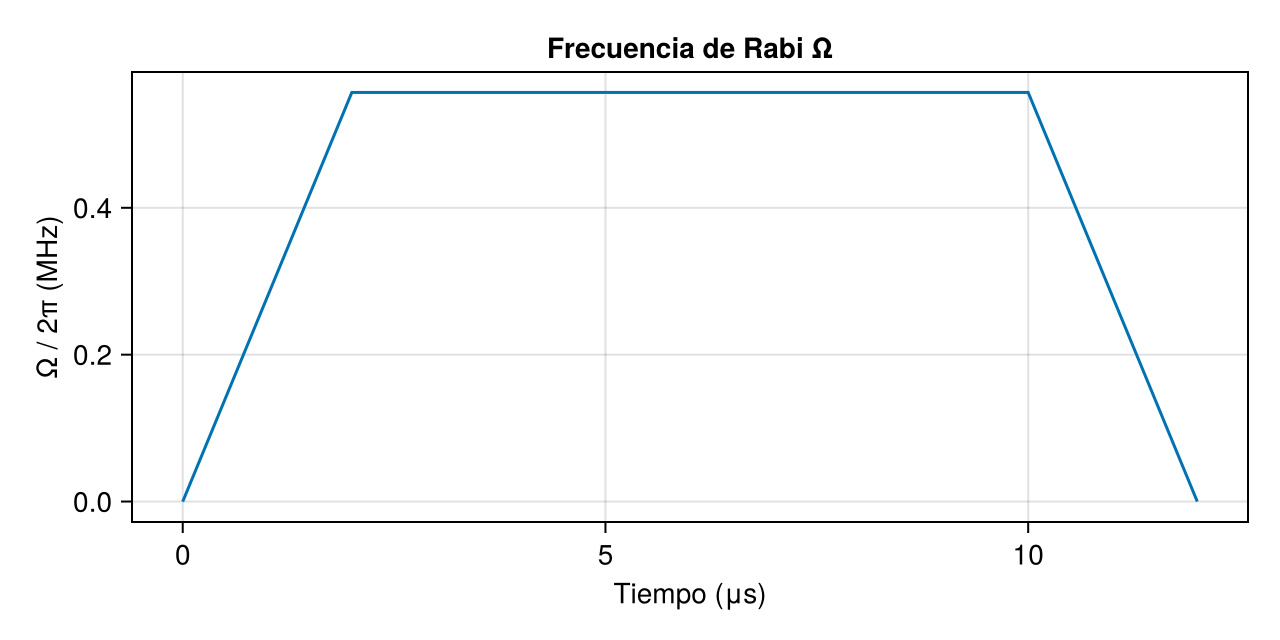

In [121]:
N = length(posiciones)
t_max = 12.0 #Tiempo de evolución en μs.
t_ramp = 2.0 #Tiempo de encendido y apagado suave.

#Frecuencia de rabi. Pulso trapezoidal.
Ω_max = 2π * 3.5
Ω = piecewise_linear(clocks = [0.0, t_ramp, t_max - t_ramp, t_max], values = [0.0, Ω_max, Ω_max, 0.0])

#Representación gráfica de los pulsos:
fig = Figure(size = (640,320))
ax1 = Axis(fig[1,1], xlabel = "Tiempo (μs)", ylabel = "Ω / 2π (MHz)", title = "Frecuencia de Rabi Ω")
Bloqade.plot!(ax1, Ω / (2π))
fig

Para el detuning hay que tener mayor cuidado, vamos a generar un pulso local para cada uno de los activos para introducir los términos lineales $Q_{ii}$.

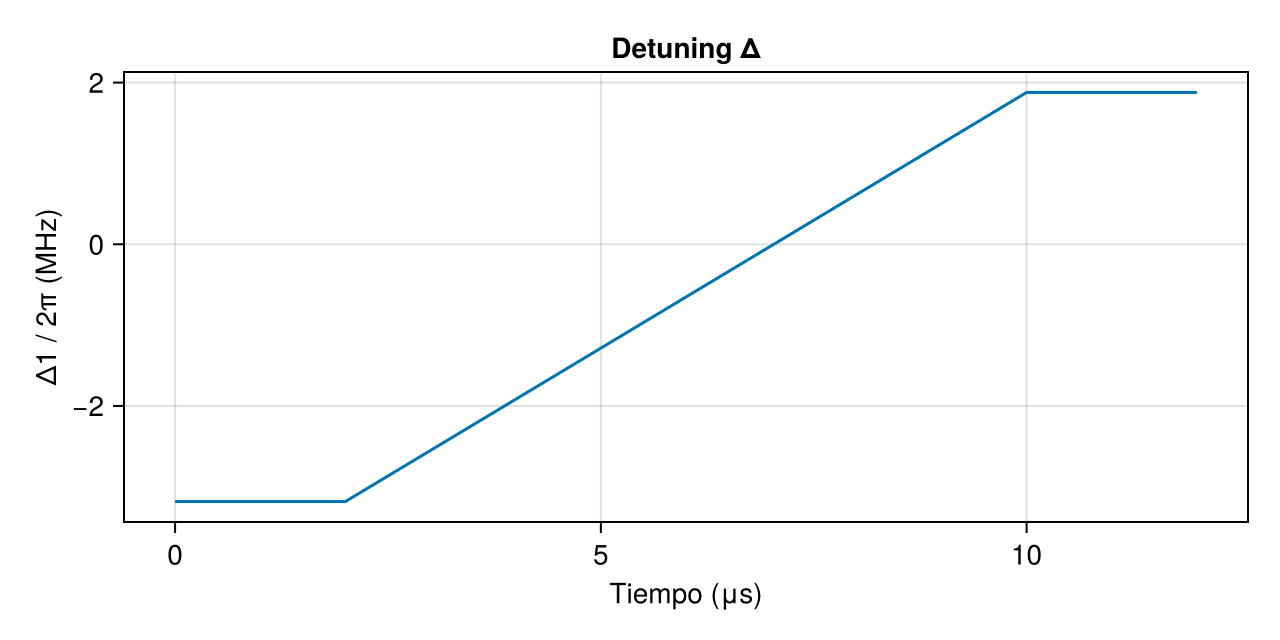

In [122]:
#Detuning. Barrido de negativo a positivo.
Δ_min = -2π * 20.0
factor_escala = 0.1
Δ_locales = map(1:N) do i
    #Obtenemos el valor Q_ii, lo reescalamos y lo pasamos a rad/μs
    sesgo_local = -2π * (Q[i,i] * factor_escala)
    #Creamos el pulso
    piecewise_linear(clocks = [0.0, t_ramp, t_max - t_ramp, t_max], values = [Δ_min, Δ_min, sesgo_local, sesgo_local])
end;
fig = Figure(size= (640,320))
ax1 = Axis(fig[1,1], xlabel = "Tiempo (μs)", ylabel = "Δ1 / 2π (MHz)", title = "Detuning Δ")
Bloqade.plot!(ax1, Δ_locales[1] / (2π))
fig

Construimos el hamiltoniano del sistema:

In [123]:
H_QUBO = rydberg_h(atoms; Ω = Ω, Δ = Δ_locales)

nqubits: 4
+
├─ [+] ∑ 2π ⋅ 8.627e5.0/|x_i-x_j|^6 n_i n_j
├─ [+] Ω(t) ⋅ ∑ σ^x_i
└─ [-] ∑ Δ_i ⋅ n_i


Podemos pasar a la simulación del sistema:

In [124]:
estado_inicial = zero_state(N)
prob = SchrodingerProblem(estado_inicial, t_max, H_QUBO)
integrador = init(prob, Vern8())
solve!(integrador);

Una vez tenemos el problema resuelto, pasamos a realizar las medidas para obtener cuál es la configuración más probable.

In [125]:
N_shots = 20000
resultados = measure(prob.reg, nshots = N_shots)

cadenas_binarias = [join(digits(Int(res), base=2, pad=N)) for res in resultados]
conteo = countmap(cadenas_binarias)
carteras_ordenadas = sort(collect(conteo), by=x->x[2], rev = true)

println("\n=== TOP 3 CARTERAS RECOMENDADAS POR EL HARDWARE ===")
for i in 1:min(3, length(carteras_ordenadas))
    cartera_bits = carteras_ordenadas[i][1]
    probabilidad = (carteras_ordenadas[i][2] / N_shots) * 100
    
    # Traducimos el "1" a la decisión de compra
    activos_comprados = [Activos[j] for j in 1:N if cartera_bits[j] == '1']
    
    # Si la cadena no tiene ningún 1 (raro pero posible), evitamos que falle
    texto_compra = isempty(activos_comprados) ? "Ninguno" : join(activos_comprados, " y ")
    
    println("$(i). Probabilidad: $(round(probabilidad, digits=1))% -> Comprar: $texto_compra")
end



=== TOP 3 CARTERAS RECOMENDADAS POR EL HARDWARE ===
1. Probabilidad: 100.0% -> Comprar: blue y white
